# Tracing LLM calls with Phoenix

This notebook marks the end of the development of the initial agent which turns a text, for example an email, into a formatted TODO list. From a user perspective the agent certainly performs worse than what a frontier model can deliver using a single prompt. If your goal is to learn about a perfect TODO generator, move on. This is a lab and some general comments on agent development. 

The previous notebooks explored:

- using the [LangGraph message reducer](../session3/langgraph_messages.ipynb) for message observation and transformation
- how subgraphs help with [data minimization (PII)](../session4/langgraph.ipynb) and deterministic guards

Before we dive into tools and give the agent true power few words on [Arize Phoenix](https://docs.arize.com/phoenix) . Phoenix is part of the lab setup ever since to trace agents, because, as Phoenix puts it: "Without tracing, you’re flying blind". And, who wants to be blind when you give powers to your agent, and the chaos spreads?

Phoenix comes with a [local UI](https://localhost:6006) and self-hosting involves way less wheels spinning than [Langfuse](https://langfuse.com/). The Langfuse [docker-compose.yaml](https://github.com/langfuse/langfuse/blob/main/docker-compose.yml) shows Clickhouse, Minio, Redis, Postgres and Langfuse itself versus a single Phoenix service and a shared Postgres instance. Since Postgres is part of the setup anyway and all we need is a trace, the choice is simple. At this point, there's no benefit in using the more sophisticated Langfuse option for the Lab. Neither from a functional nor non-functional standpoint - it works and scalability is no concern. 

## Tracing per request

In the Lab (OpenAI-) clients either use a:

- a clean path
- a chaos path

Each runs on its own endpoint. The clean path is:

- Client
- Caddy (TLS proxy)
- LiteLLM (OpenAI Gateway) <-- Arize Phoenix callback for "litellm-clean"
- Provider or ollama

In this path, LiteLLM calls Phoenix at the granule of a request. Recordings from this path are configured to be grouped together in the Phoenix "litellm-clean" project. 

The chaos path is:

- Client
- Caddy
- Toxiproxy (a proxy to inject errors) "edge_chaos"
- LiteLLM <-- Arize Phoenix callback for "litellm-chaos"
- Toxiproxy "provider_chaos_ollama" 
- Provider or ollama

Traces that belong to this path show up as "litellm-chaos" Phoenix project. 

Note the granule of these traces. The granule is per request, not per any logical application side unit such as a graph. Each and every LLM call shows as a distinct entry in the trace. Given nothing but the trace it is difficult if not impossible to reconstruct the calls that belong to a agent run. Also, it is a flat sequence - the trace will not show the hierarchy of the steps leading to the sequence. 

Both "litellm-clean" and "litellm-chaos" Phoenix projects configured and used from session 1 on. In other words: you will always see all requests being traced in one or the other project in addition to any other path to Phoenix (see below) that may apply. 

## Tracing per graph run (app-side)

As long as an agent is a plain sequence of LLM calls, a sequential trace - assuming no concurrent calls - is a great help. But with tool loops (ReAct) around the corner a tree view is way more useful to visualize a graph invocation to assist with debugging and to foster an understanding what actually happens on the line. 

For the tree view we need a third path more rooted on the client side:

 - Client start
 - register LangChainInstrumentor with Phoenix 
 - AND register OpenAIInstrumentor with Phoenix
 - using same "project" name "langgraph-course"

Registration happens very early, at latest before a graph is invoked. LangChainInstrumentor catches the structure of the tree, of the span. OpenAIInstrumentor adds all the OpenAI (LLM) calls that the aforementioned LangChainInstrumentor might miss. Together they provide a complete picture of the span.

In the code below `enable_langgraph_tracing()` from `src/tracing/phoenix.py` implements the necessary steps to register the instrumentors. All the phoenix project names are configured using environment variables (`container/compose/.env.example`). 

The function `flush_langgraph_traces()` is a convenience/utility called after the graph invocation. As the name hints it flushes pending data out to Phoenix so that you can observe the trace in the UI when the graph run is over, and possibly before pending data would have eventually been sent via the async Open Telemetry Protocol in batch mode otherwise. 

In [1]:
import sys

# Dev/Jupyter: repo root on path (same as session 4 notebook).
sys.path.insert(0, "/workspace")

# IMPORT ORDER: run this cell before langgraph, langchain llm_nodes, or any AsyncOpenAI use.
from src.tracing.phoenix import enable_langgraph_tracing, flush_langgraph_traces
# Enable tracing: this will default to "langgraph-course" Phoenix project.
enable_langgraph_tracing(batch=True, verbose=False)

import os

endpoint = os.getenv("PHOENIX_COLLECTOR_ENDPOINT")
if not endpoint:
    raise RuntimeError(
        "Missing PHOENIX_COLLECTOR_ENDPOINT. "
        "Set it in container/compose/.env and restart the dev container."
    )
print(endpoint)
# Caddy :6006 needs https (not http). https uses /certs CA automatically; or use http://phoenix:6006/v1/traces

https://caddy:6006/v1/traces


## Continue as before

The flow continues as before with a minor refactoring compared to `src/assorted/session4/langgraph.ipynb`: the wiring of the parent graph has been moved out of the notebook into library code. 

In [2]:
from typing import Callable

import logging

from IPython.display import Image, display
from langchain_core.messages import HumanMessage

from src.llm_nodes.global_state import GlobalState
from src.logging_setup import get_logger
from src.reducer.base_reader import BaseReducerReader
from src.reducer.reducer_session import reducer_session
from src.graphs.parent_base_graph import build_parent_base_graph

# MODEL = "ollama_chat/llama3.2:3b"
# MODEL = "groq/llama-3.3-70b-versatile"
MODEL = "groq-qwen3.6-27b"

pii_email = """
This is a confidential email.

Task ulf.wendel@ phpdoc dot de to buy a cup of coffee, ulf.wendel@phpdoc.de needs to plant a tree by tomorrow,
and cto@ourcompany.com needs to reach out to all employees 
regarding the current coffee shortage as it is demotivating our technical staff.
Due date, if not said otherwise, is today.
"""

logger = get_logger(__name__, "assorted/session5/graphtrace.ipynb")
logger.setLevel(logging.INFO)

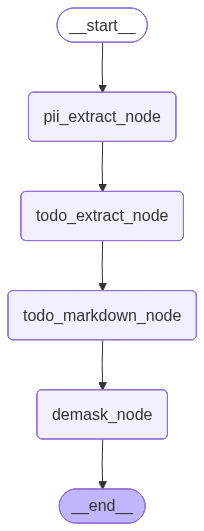

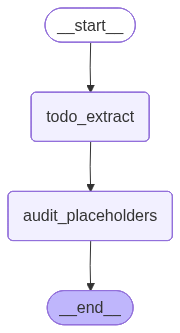

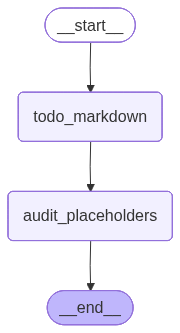

In [3]:
parent_graph = build_parent_base_graph(MODEL)
graph = parent_graph.graph
display(Image(graph.get_graph().draw_mermaid_png()))
display(Image(parent_graph.get_subgraph("todo_extract").get_graph().draw_mermaid_png()))
display(Image(parent_graph.get_subgraph("todo_markdown").get_graph().draw_mermaid_png()))

In [4]:
print("----")
print("")
print("Original text:")
print(pii_email)

----

Original text:

This is a confidential email.

Task ulf.wendel@ phpdoc dot de to buy a cup of coffee, ulf.wendel@phpdoc.de needs to plant a tree by tomorrow,
and cto@ourcompany.com needs to reach out to all employees 
regarding the current coffee shortage as it is demotivating our technical staff.
Due date, if not said otherwise, is today.



### Invoke

Note the optional `flush_langgraph_traces()` call. 

In [5]:
def make_reader(get_thread_id: Callable[[], str]):
    return BaseReducerReader(get_thread_id=get_thread_id)


reducer = None
with reducer_session("Chat-ABC", factory=make_reader) as session:

    reducer = session.reducer

    state = session.state(GlobalState, [HumanMessage(content=pii_email)])
    reply = await session.ainvoke(graph, state)
    flush_langgraph_traces()

    state = GlobalState.model_validate(reply)
    logger.debug("Observed, raw messages with content:")
    for m in state.messages:
        if hasattr(m, "content") and isinstance(m.content, str):
            logger.debug(f"{m.type}: {m.content}")

    print("----")
    print("")
    print("Graph invocation completed.")
    print("(Check console + Phoenix for Observe-tier markers even on success — ADR 0012.)")
    print("")

    print("Email extraction result from global state:")
    print(f"\tmasked text:\n{state.pii_email.text}\n")
    # print(f"\toccurrences: {[(o.span, o.raw_llm, o.placeholder) for o in state.pii_email.occurrences]}")
    print(f"\temails:\n{state.pii_email.emails}")
   
    print("")
    print("TODO list from global state:")
    for k, item in enumerate(state.todo_list.items):
        print(f"  {k + 1}): who={item.who}, what={item.what}, when={item.when}")

    print("")
    print("TODO deliverable from global state (demasked by demask_node in graph):")
    print(state.final_result)

----

Graph invocation completed.
(Check console + Phoenix for Observe-tier markers even on success — ADR 0012.)

Email extraction result from global state:
	masked text:

This is a confidential email.

Task E0_cea09c31 to buy a cup of coffee, E0_cea09c31 needs to plant a tree by tomorrow,
and E1_cea09c31 needs to reach out to all employees 
regarding the current coffee shortage as it is demotivating our technical staff.
Due date, if not said otherwise, is today.


	emails:
['ulf.wendel@phpdoc.de', 'cto@ourcompany.com']

TODO list from global state:
  1): who=E0_cea09c31, what=buy a cup of coffee, when=today
  2): who=E0_cea09c31, what=plant a tree, when=tomorrow
  3): who=E1_cea09c31, what=reach out to all employees regarding the current coffee shortage, when=today

TODO deliverable from global state (demasked by demask_node in graph):
# ulf.wendel@phpdoc.de
- [ ] buy a cup of coffee (by today)
- [ ] plant a tree (by tomorrow)

# cto@ourcompany.com
- [ ] reach out to all employees reg

## PII in the graph

With all this in place, what you get in the Phoenix UI at Phoenix -> Tracing -> Spans is a detail view of the graph run execution such as: 

![Example trace](trace_example.png)

(Note: the example may not show the latest run from the notebook.)

The left panel shows the span hierarchy: the pipeline as nested steps. On the right side is a single selected span. Here the root is typed as a LangChain chain. 

Note that trace shows PII, and be warned that the Lab does not try to implement any access control and security measures: why would it - you have the source anyway...